<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/praktikum/praktikum/praktikum12/notebooks/praktikum12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Praktikum 12 - PCA**

*   **Nama:** Maryam Hasnaa' Syamila
*   **NIM:** 0110222067



#### **1. Import Library**

In [ ]:
# import library
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = (8,6)

#### **2. Load Dataset**

In [ ]:
# load dataset wine
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# tampilkan 5 baris pertama
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### **3. Explorasi Awal Dataset**

In [ ]:
# info umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
# statistik deskriptid
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
# cek missing value
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [ ]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# distribusi kelas target
print("Nama kelas:", wine.target_names)
df['target'].value_counts()

Nama kelas: ['class_0' 'class_1' 'class_2']


,count
target,
1,71
0,59
2,48


#### **4. Pemisahan Fitur dan Label**

In [ ]:
# fitur dan label
X = wine.data
y = wine.target

print("Shape x:", X.shape)
print("Shape y:", y.shape)

Shape x: (178, 13)
Shape y: (178,)


#### **5. Pembagian Data Train dan Data Test (Train-Test Split)**

In [ ]:
# train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape x train:", X_train.shape)
print("Shape y train:", y_train.shape)

Shape x train: (142, 13)
Shape y train: (142,)


#### **6. Standardisasi Data (Mean = 0, STD = 1)**

In [ ]:
# standarisasi (mean = 0, std = 1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.38580089, -0.63787118,  1.77666817, -1.22453161,  0.69643032,
         0.52686525,  0.73229212, -0.1695489 , -0.41578344, -0.16746725,
         0.62437819,  0.2529082 ,  0.46772474],
       [ 0.94851892, -0.76544542,  1.25317383,  0.85328406,  0.09178497,
         1.17279546,  1.33318146, -0.59045701,  1.34974202,  0.30530313,
         1.06715537,  0.15104809,  1.81576773],
       [ 0.52335419, -0.51940939,  0.9540342 , -1.04643312, -0.44567755,
         0.93057163,  1.006382  , -0.1695489 , -0.26000178, -0.081509  ,
        -0.12834302,  0.89317174,  1.51620262],
       [ 0.97352861, -0.55585917,  0.16879269, -1.0761162 , -0.71440882,
         0.52686525,  0.81662747, -0.59045701,  0.36312485,  0.262324  ,
         0.8900445 ,  0.42752553,  1.93226527],
       [ 0.43582027,  0.82012009,  0.05661533,  0.55645325, -0.51286037,
        -0.55506784, -1.29175618,  0.75644894, -0.60618325,  1.47433535,
        -1.76661859, -1.43505932, -0.29783054]])

#### **7. Penerapan Model SVM tanpa PCA (Baseline Model)**

In [ ]:
# model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

# prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi SVM tanpa PCA:", acc_no_pca)

print("\nClassification Report (tanpa PCA)")
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))

Akurasi SVM tanpa PCA: 0.9722222222222222

Classification Report (tanpa PCA)
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



#### **8. Penerapan PCA (Principal Component Analysis**

In [ ]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca:", X_test_pca.shape)

Shape X_train_pca: (142, 3)
Shape X_test_pca: (36, 3)


In [ ]:
# variansi yang dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio tiap komponen:", explained_var)
print("Total variansi yang dijelaskna 3 komponen pertama:", explained_var.sum())

Explained Variance Ratio tiap komponen: [0.35792104 0.19270671 0.11019835]
Total variansi yang dijelaskna 3 komponen pertama: 0.6608261082211259


#### **9. Menampilkan Variansi yang Dijelaskan oleh Setiap Komponen PCA**

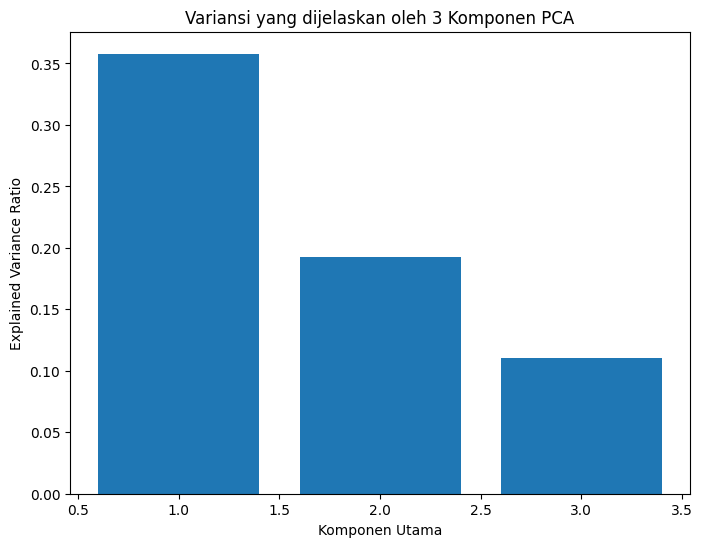

In [ ]:
# visualisasi variansiyang dijelaskan oleh 3 komponen PCA
plt.bar([1,2,3], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi yang dijelaskan oleh 3 Komponen PCA')
plt.show()

#### **10. Membangun Model SVM dengan PCA**

In [ ]:
# bangun model svm tanpa PCA

# model svm dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# prediksi dan evaluasi
y_pred_no_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi SVM dengan PCA (3 komponen):", acc_pca)

print("\nClassification Report (dengan PCA)")
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))

Akurasi SVM dengan PCA (3 komponen): 0.9722222222222222

Classification Report (dengan PCA)
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



#### **11. Visualisasi PCA dalam Ruang 3 Dimensi**

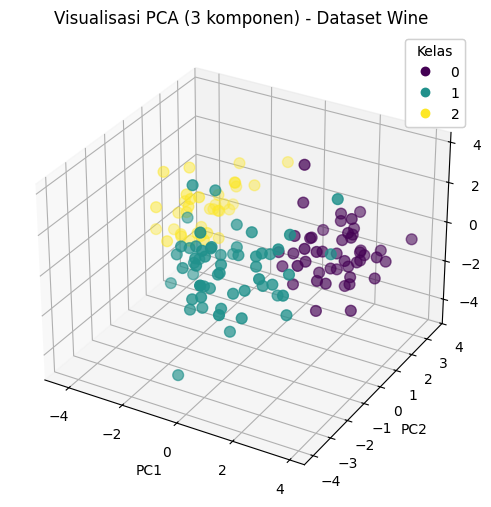

In [ ]:
# visualisasi 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    X_train_pca[:,2],
    c=y_train,
    s=60
)

ax.set_title('Visualisasi PCA (3 komponen) - Dataset Wine')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# tambahkan legend berdasarkan kelas
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Kelas"
)
ax.add_artist(legend1)
plt.show()

#### **12. Perbandingan Model SVM Tanpa PCA dan Dengan PCA**

In [ ]:
# membandingkan hasil model tanpa PCA dan dengan PCA
comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA (3 komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, explained_var.sum()]
})

comparison

,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM tanpa PCA,13,0.972222,NaN
1,SVM dengan PCA (3 komponen),3,0.972222,0.660826


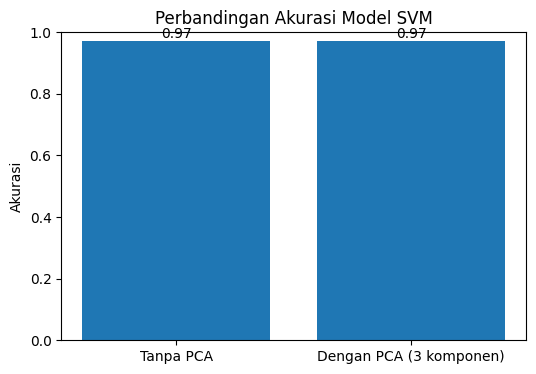

In [ ]:
# visualisasi grafik
plt.figure(figsize=(6,4))
plt.bar(['Tanpa PCA', 'Dengan PCA (3 komponen)'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model SVM')
plt.ylabel('Akurasi')
plt.ylim(0,1)
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v+0.01, f'{v:.2f}', ha='center')
plt.show()

#### **Kesimpulan Akhir**

1. Proses reduksi dimensi dengan PCA berhasil mengubah 13 fitur asli menjadi 3 komponen utama
(PC1, PC2, dan PC3). Ketiga komponen tersebut mampu menjelaskan sekitar 66.08% variansi total dari data asli, yang berarti sebagian besar informasi masih dapat dipertahankan.
2. Model SVM tanpa PCA dan model SVM dengan PCA (3 komponen) menunjukkan akurasi yang sama tinggi, yaitu 97.22%. Hal ini membuktikan bahwa penerapan PCA tidak menurunkan performa klasifikasi meskipun jumlah fitur berkurang drastis.
3. Visualisasi 3D PCA menunjukkan bahwa data dari tiga kelas (class_0, class_1, dan class_2) dapat terpisah dengan cukup baik pada ruang tiga dimensi hasil transformasi PCA, menandakan bahwa komponen utama berhasil menangkap struktur data yang relevan.
4. Dengan menerapkan PCA, model menjadi lebih efisien secara komputasi, karena bekerja dengan jumlah fitur yang lebih sedikit, namun tetap mempertahankan kinerja prediksi yang sangat baik.
5. PCA juga membantu mengurangi risiko overfitting, terutama pada dataset dengan dimensi tinggi, karena menghilangkan korelasi antar fitur dan menyederhanakan representasi data.

